## Whisper-Tiny for Banking ASR on the MINDS-14 Dataset
This hands-on project demonstrates finetuning the <b>Whisper-tiny</b> ASR model from the Hugging Face Hub on the <b>en-US</b> subset of <b>PolyAI/minds14</b> dataset.

<b>Whisper-tiny</b> is the smallest variant of the Seq2Seq Whisper architecture, released in 2022 by OpenAI. With 39 million parameters, it is approximately 32 times faster than the "large" variant. <br>
<b>MINDS-14</b> is a spoken data resource for intent detection in the e-banking domain. Despite Whisper being a powerful speech recognition model, the tiny variant shows roughly 38% WER on the English part of this dataset out of the box.  That means more than one-third of the words are incorrectly transcribed. This notebook provides a deeper dive into the specific reasons for these errors and demonstrates techniques to mitigate them.

This project is based on the <a href="https://huggingface.co/learn/audio-course/en/chapter5/hands_on"> Unit 5</a> assignment from the Hugging Face Audio Course. Notably, the presented approach achieves the WER of <b>0.2936</b> (29.36%), while the course's target was getting WER lower than <b>0.37</b> (37%).

#### Importing the needed dependencies

In [1]:
import re
import random
import logging
import matplotlib.pyplot as plt
import numpy as np
import textwrap

from collections import namedtuple, Counter
from functools import partial
from typing import Any, Dict, List, Union

from datasets import Audio, load_dataset, DatasetDict
from dataclasses import dataclass
from huggingface_hub import notebook_login

import evaluate
from jiwer import wer as jiwer_wer 

import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from transformers import WhisperForConditionalGeneration, WhisperProcessor, WhisperTokenizer
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, GenerationConfig, EarlyStoppingCallback
from transformers.models.whisper.english_normalizer import BasicTextNormalizer

Authentication is required to use the Hugging Face Hub.

In [2]:
notebook_login()

### Loading and preparing the dataset

In [3]:
minds_14 = load_dataset("PolyAI/minds14", "en-US")

In [4]:
def print_dataset_info(dataset):
    print("Splits:")
    bold_start, bold_end = "\033[1m", "\033[0m"    
    for split in dataset.keys():
        num_rows = dataset[split].num_rows
        features = ", ".join(dataset[split].features)        
        print(f"  {bold_start}{split}{bold_end}:")
        print(f"    num_rows: {num_rows}")
        print(f"    features: {features}")

In [5]:
print_dataset_info(minds_14)

Splits:
  train:
    num_rows: 563
    features: path, audio, transcription, english_transcription, intent_class, lang_id


The dataset provides a <span style="color: #2980b9;">**train**</span> split only. Creating a <span style="color: #2980b9;">**train/test**</span> split manually:

In [6]:
minds_14 = minds_14["train"].train_test_split(seed=45, shuffle=True, test_size=0.2)
print_dataset_info(minds_14)

Splits:
  train:
    num_rows: 450
    features: path, audio, transcription, english_transcription, intent_class, lang_id
  test:
    num_rows: 113
    features: path, audio, transcription, english_transcription, intent_class, lang_id


The only features needed for this task are <span style="color: #2980b9;">**audio**</span> and <span style="color: #2980b9;">**transcription**</span> (identical to <span style="color: #2980b9;">**english_transcription**</span> in the en-US subset). Dropping the unused columns.

In [7]:
minds_14 = minds_14.select_columns(["audio", "transcription"])
print_dataset_info(minds_14)

Splits:
  train:
    num_rows: 450
    features: audio, transcription
  test:
    num_rows: 113
    features: audio, transcription


Matching the dataset audio sampling rate and the model sampling rate is crucial for finetuning. Let's see more details on the <span style="color: #2980b9;">**audio**</span> feature.

In [8]:
print("Minds14 audio:", minds_14["train"].features["audio"])

Minds14 audio: Audio(sampling_rate=8000, mono=True, decode=True, id=None)


Now compare that with the Whisper feature extractor sampling rate:

In [9]:
processor = WhisperProcessor.from_pretrained("openai/whisper-tiny", language="en", task="transcribe")

In [10]:
feature_extractor = processor.feature_extractor
print(f"Target sampling_rate: {feature_extractor.sampling_rate} Hz.")

Target sampling_rate: 16000 Hz.


The resampling from <span style="color: #2980b9;">**8000 Hz**</span> to <span style="color: #2980b9;">**16000 Hz**</span> is to be done:

In [11]:
minds_14 = minds_14.cast_column("audio", Audio(sampling_rate=feature_extractor.sampling_rate, decode=True))

In [12]:
print("Minds14 audio:", minds_14["train"].features["audio"])

Minds14 audio: Audio(sampling_rate=16000, mono=True, decode=True, id=None)


Use the processor to prepare the dataset samples by converting raw audio into Log-Mel Spectrograms and tokenizing the transcriptions. Additionally, The <span style="color: #2980b9;">**input_length**</span> feature calculated to monitor the duration of each sample.

In [13]:
def prepare_dataset(sample):    
    sample_processed = processor(
        # Generate log-mel spectrograms from the audio
        audio=sample["audio"]["array"],
        sampling_rate=sample["audio"]["sampling_rate"],
        # Tokenize the transcription text
        text=sample["transcription"]
    )

    # Add metadata for sample duration
    sample_processed["input_length"] = len(sample["audio"]["array"]) / sample["audio"]["sampling_rate"]

    return sample_processed

Let's see how the dataset samples are transformed

In [14]:
random_index = random.randint(0, len(minds_14["train"]) - 1)
sample = minds_14["train"][random_index]

print(f"--- [BEFORE]---")
print()

print(f"Text: \"{sample['transcription']}\"")

raw_audio = sample['audio']['array']
print(f"Audio Shape: {raw_audio.shape} (1D array / Mono)")
print(f"Sampling Rate: {sample['audio']['sampling_rate']} Hz")
print(f"Total Samples: {len(raw_audio)}")

--- [BEFORE]---

Text: "hi I'm trying to make a large purchase online and it's saying that I'm going to receive an SMS message code and I'm not sure what to do"
Audio Shape: (181590,) (1D array / Mono)
Sampling Rate: 16000 Hz
Total Samples: 181590



--- [AFTER] ---

Spectrogram  : 80 mel bins x 3000 time frames
Audio length : 11.35 seconds
Token IDs    : [50258, 50259, 50359, 50363, 4954, 286, 478, 1382, 281, 652]... (Total: 37 tokens)
Text decoded : "hi I'm trying to make a large purchase online and it's saying that I'm going to receive an SMS message code and I'm not sure what to do"


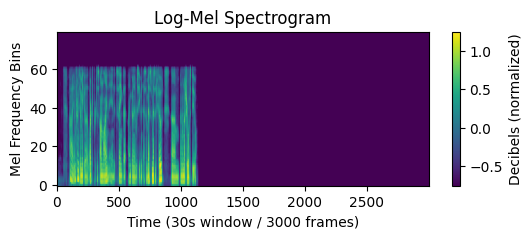

In [15]:
# Process the sample
processed = prepare_dataset(sample)

# The numerical results
print(f"\n--- [AFTER] ---")
print()

# input_features is usually a list containing one array, so take the [0]
input_features = np.array(processed["input_features"][0])

# labels is just a flat list of IDs for a single sample
labels = processed["labels"] 

# Input length calculated
input_length = processed["input_length"]

print(f"Spectrogram  : {input_features.shape[0]} mel bins x {input_features.shape[1]} time frames")
print(f"Audio length : {input_length:.2f} seconds")
print(f"Token IDs    : {labels[:10]}... (Total: {len(labels)} tokens)")
print(f"Text decoded : \"{processor.tokenizer.decode(labels, skip_special_tokens=True)}\"")


# The Log-Mel Spectrogram
plt.figure(figsize=(6, 2))
plt.imshow(input_features, aspect='auto', origin='lower', cmap='viridis')
plt.title(f"Log-Mel Spectrogram")
plt.colorbar(label='Decibels (normalized)')
plt.ylabel("Mel Frequency Bins")
plt.xlabel("Time (30s window / 3000 frames)")
plt.show()

The mismatch between the <span style="color: #2980b9;">**Audio length**</span> (which varies by sample) and the <span style="color: #2980b9;">**Spectrogram**</span> (which always represents 30s) comes from <span style="color: #2980b9;">**Zero-Padding**</span>. Whisper's feature extractor pads any audio shorter than 30 seconds with silence to ensure a consistent input shape for the model's encoder.

It is worth noting that tokens produced by the tokenizer do not correspond directly to words, as Whisper utilizes <span style="color: #2980b9;">**Byte Pair Encoding (BPE)**</span>, a sub-word tokenization method. Unlike simple whitespace tokenization, BPE breaks words down into smaller chunks (e.g., the word "depositing" might be split into ["deposit", "ing"]). 

In [16]:
labels_count = 10
decoded_str = processor.tokenizer.decode(labels[:labels_count], skip_special_tokens=True)
words = decoded_str.split(" ")
print(f'Text: "{decoded_str}"')
print(f"Tokens count: {labels_count}")
print(f"Words count:  {len(words)}")

Text: "hi I'm trying to make"
Tokens count: 10
Words count:  5


Now, apply the <span style="color: #2980b9;">**prepare_dataset**</span> function to the entire dataset. <br>
The <span style="color: #2980b9;">**remove_columns**</span> parameter is used to drop original raw features, as they are no longer needed for training and would only consume extra RAM.

In [17]:
original_column_names = minds_14.column_names["train"]

minds_14 = minds_14.map(
    prepare_dataset, 
    remove_columns=original_column_names, 
    num_proc=1
)

Filter the dataset to retain only audio samples shorter than 30 seconds. Since Whisper operates on fixed 30-second input windows, longer samples may be truncated during preprocessing.

In [18]:
MAX_INPUT_LENGTH = 30.0

def is_audio_in_length_range(length):
    return length < MAX_INPUT_LENGTH

minds_14["train"] = minds_14["train"].filter(
    is_audio_in_length_range,
    input_columns=["input_length"]
)

In [19]:
print_dataset_info(minds_14)

Splits:
  train:
    num_rows: 447
    features: input_features, labels, input_length
  test:
    num_rows: 113
    features: input_features, labels, input_length


**Defining the Data Collator** <br>
In the Hugging Face ecosystem, a <span style="color: #2980b9;">**DataCollator**</span> is a specialized component that gathers individual samples from a dataset and unites them into the batch.

The data collator for a sequence-to-sequence speech model should treat the audio inputs and text labels separately:

*   **Audio Inputs**: Since the audio has already been converted into fixed-length 30-second spectrograms, the collator simply stacks these into a unified PyTorch tensor, without any additional padding applied. Nevertheless, the attention mask is explicitly included to help the encoder distinguish signal from silence.
*   **Text Labels**: Unlike the audio, text transcriptions vary in length. The collator dynamically pads these labels to the maximum length found within each specific batch.

Additional steps performed:
*   **Loss Masking**: Padding tokens are replaced by a specific index. This ensures these positions are not taken into account when computing the loss, preventing the model from trying to "learn" the padding.
*   **BOS Cleanup**: Any leading "Beginning of Sentence" (BOS) tokens are stripped, as the Whisper decoder automatically appends its own prefix tokens during the training process.

The already created <span style="color: #2980b9;">**WhisperProcessor**</span> performs both the feature extraction and tokenization logic within this class.


In [20]:
# Readable type aliases
Spectrogram = torch.Tensor 
TokenIDs = List[int]
DatasetSample = Dict[str, Union[Spectrogram, TokenIDs]]

# Standard index to ignore padding during loss calculation
LOSS_IGNORE_INDEX = -100

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, samples: List[DatasetSample]) -> Dict[str, torch.Tensor]:
        # Handle Audio (Encoder Inputs)        
        # Take the [0] element to remove the dummy batch dimension created by the processor
        input_features = [{"input_features": s["input_features"][0]} for s in samples]        
        
        # Since Whisper spectrograms are already fixed-length (30s / 3000 frames), 
        # the feature_extractor simply stacks them into a batch tensor.
        # The attention_mask is explicitly returned to let the 
        # encoder know which parts of the 30s window contain the actual audio signal.
        batch = self.processor.feature_extractor.pad(
            input_features, 
            return_tensors="pt", 
            return_attention_mask=True
        )

        # Handle Text (Decoder Labels)
        # Text labels vary in length and require dynamic padding 
        # to match the longest sentence in this specific batch.
        label_features = [{"input_ids": s["labels"]} for s in samples]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # Mask Padding in Labels
        # The attention_mask is '1' for real tokens and '0' for padding.
        # Replacing padding where mask!=1 with LOSS_IGNORE_INDEX (-100) 
        # so the model's loss function ignores these positions during training.
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), 
            LOSS_IGNORE_INDEX
        )

        # Remove BOS Token
        # If present, it's stripped as the decoder adds its own start token automatically
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        # Attach the processed labels to the batch dictionary. 
        # The Trainer will pass this entire dict to the model as keyword arguments (**kwargs).
        batch["labels"] = labels

        return batch

In [21]:
data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

### Baseline Evaluation: Assessing the original pre-trained model

In [22]:
metric = evaluate.load("wer")
normalizer = BasicTextNormalizer()

**Metric Computation Logic** <br>
The following steps are performed to evaluate the model's performance in terms of **WER** and **WER Ortho**:

1. **Padding Restoration and Decoding.**
The <span style="color: #2980b9;">**DataCollator**</span> replaces padding tokens with <span style="color: #2980b9;">**-100**</span> during batch preparation to mask them from the loss function. Because the tokenizer's decoder only recognizes valid vocabulary IDs, these values must be reverted to the <span style="color: #2980b9;">**pad_token_id**</span>.

2. **Special Symbol Removal.**
Once restored, the <span style="color: #2980b9;">**batch_decode**</span> method with <span style="color: #2980b9;">**skip_special_tokens=True**</span> filters out all non-linguistic markers, such as <span style="color: #2980b9;">**BOS**</span>, <span style="color: #2980b9;">**EOS**</span>, and padding. While the <span style="color: #2980b9;">**DataCollator**</span> removed the <span style="color: #2980b9;">**BOS**</span> (Begin-of-Sequence) tokens from the label tokens, they are still generated in the model predictions. The <span style="color: #2980b9;">**EOS**</span> (End-of-Sentence) token is present in both the target labels and the model's predictions. This step ensures that the resulting <span style="color: #2980b9;">**pred_str**</span> and <span style="color: #2980b9;">**label_str**</span> contain only the meaningful transcription content.

3. **Orthographic and Normalized WER.**
Two distinct Word Error Rate (WER) metrics are calculated:
* **Orthographic WER**: A strict comparison of the raw decoded strings, preserving original casing and punctuation.
* **Normalized WER**: A comparison performed after applying the <span style="color: #2980b9;">**WhisperNormalizer**</span>, which standardizes the text by removing punctuation and capitalization to evaluate phonetic accuracy.

4. **Handling Null References.**
The normalization process can occasionally reduce a reference transcription to an empty string (e.g., if the original label contained only noise markers like *"[noise]"* or punctuation like *"???"*). Calculating WER against an empty reference results in a division-by-zero error. To maintain the integrity, any samples where the normalized reference length is zero are filtered out before the final <span style="color: #2980b9;">**metric.compute**</span> call.

In [23]:
def replace_label_padding(label_ids, pad_token_id):
    """
    Swaps the -100 ignore index back to the actual pad_token_id.
    This ensures the tokenizer can process the sequences for metric evaluation.
    """
    return [
        [token if token != LOSS_IGNORE_INDEX else pad_token_id for token in sequence]
        for sequence in label_ids
    ]

In [24]:
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # Step 1: Restore padding so tokenizer can decode
    label_ids = replace_label_padding(label_ids, processor.tokenizer.pad_token_id)

    # Step 2: Decode IDs to strings
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.batch_decode(label_ids, skip_special_tokens=True)

    # Step 3: Compute strict (orthographic) WER
    wer_ortho = metric.compute(predictions=pred_str, references=label_str)

    # Step 4: Normalize strings for fair comparison
    pred_str_norm = [normalizer(p) for p in pred_str]
    label_str_norm = [normalizer(l) for l in label_str]

    # Step 5: Filter pairs to ensure the labels are not empty
    filtered_preds = [p for p, l in zip(pred_str_norm, label_str_norm) if len(l) > 0]
    filtered_labels = [l for l in label_str_norm if len(l) > 0]

    wer = metric.compute(predictions=filtered_preds, references=filtered_labels)

    return {"wer_ortho": wer_ortho, "wer": wer}

Now loading the pre-trained checkpoint of the model. The model class is named <span style="color: #2980b9;">**WhisperForConditionalGeneration**</span> because its Encoder-Decoder architecture autoregressively generates text tokens conditioned on input audio. This distinguishes it from the encoder-only <span style="color: #2980b9;">**WhisperForAudioClassification**</span> or the base <span style="color: #2980b9;">**WhisperModel**</span> used for feature extraction.

In [25]:
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny")

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
_ = model.eval()

In [27]:
test_loader = DataLoader(
        minds_14["test"],        
        batch_size=16,
        shuffle=False,
        collate_fn=data_collator,
    )

In [28]:
def generate_predictions(model, test_loader, device, **gen_kwargs):    
    preds, labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            input_features = batch["input_features"].to(device)
            attention_mask = batch.get("attention_mask")
            
            gen_tokens = model.generate(
                input_features,
                attention_mask=attention_mask,
                **gen_kwargs
            )
            
            # Flatten and store
            preds.extend([seq.cpu().tolist() for seq in gen_tokens])
            labels.extend([seq.cpu().tolist() for seq in batch["labels"]])
            
    return preds, labels

As Whisper is a multi-task and multi-lingual model, the <span style="color: #2980b9;">**forced_decoder_ids**</span> can be used used to "pin" the model to a specific language and task. By setting these IDs, we ensure the decoder starts every generation with the internal tokens for <span style="color: #2980b9;">**English**</span> and <span style="color: #2980b9;">**Transcription**</span>, preventing the model from accidentally switching to translation or another language during the inference process.

In [29]:
forced_decoder_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")

In [30]:
baseline_generation_params = {
    "forced_decoder_ids": forced_decoder_ids,
    "pad_token_id": processor.tokenizer.pad_token_id,
    "max_length": 225,
    "use_cache": True    
}

baseline_preds, baseline_labels = generate_predictions(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    **baseline_generation_params
)

In [31]:
BaselineEvaluation = namedtuple("BaselineEvaluation", ["predictions", "label_ids"])
metrics = compute_metrics(BaselineEvaluation(predictions=baseline_preds, label_ids=baseline_labels))

In [32]:
print("Baseline evaluation:", metrics)

Baseline evaluation: {'wer_ortho': 0.5109144542772861, 'wer': 0.3760587238848108}


#### Main Error Types Analysis 

Since the baseline evaluation shows low transcription accuracy, it is useful to analyze the main sources of error.

In [33]:
pred_str_baseline = processor.batch_decode(baseline_preds, skip_special_tokens=True)

label_ids_for_decode = replace_label_padding(baseline_labels, processor.tokenizer.pad_token_id)
label_str_baseline = processor.batch_decode(label_ids_for_decode, skip_special_tokens=True)

In [34]:
def get_errors_by_type(pred_str, label_str, predicate, error_name, get_error_info=None):
    errors = []
    strip_chars = " \t\n.?!"
    
    for prediction, reference in zip(pred_str, label_str):   
        ref_clean = reference.strip(strip_chars)
        pred_clean = prediction.strip(strip_chars)
        ref_norm = normalizer(ref_clean).lower()
        pred_norm = normalizer(pred_clean).lower()

        if not ref_norm or pred_norm == ref_norm:
            continue

        ref_tokens = ref_norm.split()  
        pred_tokens = pred_norm.split()
        wer = jiwer_wer(reference, prediction)
        
        if (wer > 0.0) and predicate(ref_tokens, pred_tokens):                                                
            sample = {
                "reference": reference,
                "prediction": prediction,
                "error_type": error_name,
                "wer": wer
            }
            
            if get_error_info:
                sample["error_info"] = get_error_info(ref_tokens, pred_tokens)
                
            errors.append(sample)
            
    return errors

In [35]:
def print_error_samples(title: str, error_samples, take_top: int = 5):
    top_samples = sorted(error_samples, key=lambda s: s["wer"], reverse=True)[:take_top]
    
    print(f"\n{'='*63}")
    print(f"📊 {title.upper()} ({len(top_samples)} samples out of {len(error_samples)} errors)")
    print(f"{'='*63}")

    for i, s in enumerate(top_samples, 1):
        print(f"\n{i}. \033[1mWER :\033[0m {s['wer']:.2f}")
        
        if "error_info" in s and s["error_info"]:
            print(f"   \033[1mERR :\033[0m {', '.join(s['error_info'])}")

        ref_text = normalizer(s['reference']).strip()
        pred_text = normalizer(s['prediction']).strip()
        
        wrapper = textwrap.TextWrapper(width=110, initial_indent="", subsequent_indent="         ")
        
        print(f"   \033[1mREF :\033[0m {wrapper.fill(ref_text)}")
        print(f"   \033[1mPRED:\033[0m {wrapper.fill(pred_text)}")
        print(f"   {'-' * 60}")


##### 1. Digit Mismatch

One of the possible sources of error is the misrecognition of numeric entities. Let's see how they appear in this case:

In [36]:
number_errors_pred = (lambda rt, pt: Counter([t for t in rt if any(c.isdigit() for c in t)]) != 
                                     Counter([t for t in pt if any(c.isdigit() for c in t)]))

def get_numeric_info_pred(ref_tokens, pred_tokens):    
    ref_nums = Counter([t for t in ref_tokens if any(c.isdigit() for c in t)])
    pred_nums = Counter([t for t in pred_tokens if any(c.isdigit() for c in t)])    
    diff = ref_nums - pred_nums    
    return list(diff.keys())

In [37]:
# 1. Digit mismatch
number_errs = get_errors_by_type(
    pred_str_baseline, label_str_baseline, 
    predicate=number_errors_pred, 
    error_name="numbers_mismatch",
    get_error_info=get_numeric_info_pred    
)

print_error_samples("Numbers mismatch", number_errs)


📊 NUMBERS MISMATCH (2 samples out of 2 errors)

1. WER : 0.39
   ERR : 18
   REF : hi i m an account holder have been for 18 years and i d like to speak to somebody about taking out a business
         loan
   PRED: hi i m at a caf holder i ve been for 10 years and i d like to speak to somebody about taking out a business
         loan
   ------------------------------------------------------------

2. WER : 0.28
   ERR : 2
   REF : hello i am called because i want to ask about using my card in nigeria i ll be going there in about 2 weeks
         and i just wanted to call to see if i needed anything to my account is there anything i need to do
         before using gift card in nigeria thank you
   PRED: come on i call it because i want to ask about using my card in nigeria i ll be going there in about two weeks
         and i just wanted to call it to see if i needed to change anything to my account if there anything i
         need to do before using this card in nigeria thank you


So, the errors in this category can manifest in two ways:
- <b>Phonetic Substitution</b>: The model mishears the number (e.g., transcribing "18" as "10").
- <b>Format Inconsistency</b>: The model transcribes the number as a word (e.g., "two") instead of a digit ("2"), which increases the WER despite phonetic accuracy.

##### 2. Banking terms misrecognition

Despite the English language, the presence of specialized banking terminology can noticeably affect recognition quality:

In [38]:
banking_keywords = {
    "account",
    "address",
    "app",
    "atm",
    "balance",
    "bank",
    "bill",
    "card",
    "cash",
    "checking",
    "debit",
    "debits",
    "declined",
    "deposit",
    "error",
    "freeze",
    "joint",
    "loan",
    "payment",
    "pin",
    "routing",
    "savings",
    "security",
    "transaction",
    "transactions",
    "transfer"
}
banking_err_pred = lambda rt, pt: any(kw in rt and kw not in pt for kw in banking_keywords)
banking_info_pred = lambda rt, pt: {kw for kw in rt if kw in banking_keywords and kw not in pt}

In [39]:
# 2. Banking terms misrecognition
bank_errs = get_errors_by_type(
    pred_str_baseline, label_str_baseline, 
    predicate=banking_err_pred, 
    error_name="banking_keyword",
    get_error_info=banking_info_pred
)
print_error_samples("Banking Terms misrecognition:", bank_errs)


📊 BANKING TERMS MISRECOGNITION: (5 samples out of 17 errors)

1. WER : 1.25
   ERR : deposit
   REF : can i deposit money
   PRED: can i do the positive money
   ------------------------------------------------------------

2. WER : 0.62
   ERR : debit
   REF : could you tell me about direct debit please
   PRED: hi could you tell me about direct habits please thank you
   ------------------------------------------------------------

3. WER : 0.56
   ERR : payment, declined
   REF : hey i bought something online but i payment was declined you help me with my card
   PRED: i thought something online but i paid it with the client can you help me with my card
   ------------------------------------------------------------

4. WER : 0.53
   ERR : loan
   REF : sampling about a pre existing a business loan that i have with you guys let s have some questions about it
   PRED: i m calling about a preexisting business plan that i have with you guys i ll tell you some questions about it
   ---

#### 3. Overgeneration in short transcriptions

The audio samples in the <span style="color: #2980b9;">**MINDS-14**</span> dataset are typically brief. However, Whisper-tiny has a known tendency to "overgenerate," extending short phrases into longer, redundant sentences. 
Whisper processes audio in fixed 30-second windows, with any shorter sample being padded with silence. Since the model was trained on diverse, long-form internet audio, the decoder sometimes fails to predict the <span style="color: #2980b9;">**EOS**</span>  (End-of-Sentence) token immediately after the speech ends. Instead, it attempts to continue the sequence based on internal linguistic patterns, leading to hallucinations or repetitive phrases.

In [40]:
overgen_pred = lambda rt, pt: len(pt) >= max(1, len(rt) * 2) or (len(pt) - len(rt)) >= 5

In [41]:
# 3. Overgeneration
overgen_errs = get_errors_by_type(
    pred_str_baseline, label_str_baseline, 
    overgen_pred, 
    "overgeneration"
)
print_error_samples("Text overgenerating:", overgen_errs)


📊 TEXT OVERGENERATING: (5 samples out of 21 errors)

1. WER : 5.23
   REF : i m thinking about withdrawing money from i want a lot of money today
   PRED: hi i m speaking to take out all the trauma from the atm i want to draw a lot of money so i m wondering what s
         the most that i can read draw today what s the maximum amount i know for some cards there is a limit
         some wondering for my specific card what is the limit because today i m just trying to withdraw as
         much of a can if my limit is less i m able to increase it
   ------------------------------------------------------------

2. WER : 2.79
   REF : i was hoping you could help me i have a card from a bank
   PRED: hi i was hoping you could help me i have a card from a bank but it is not working i have money in the bank but
         the card doesn t pay online it doesn t pay physical locations i can t get it to for many transactions
         so i need help thank you
   ------------------------------------

#### 4. Polite words hallusinations

Whisper-tiny can "hallucinate" introductory greetings such as <span style="color: #2980b9;">**"Hi"**</span> or <span style="color: #2980b9;">**"Hello"**</span> at the beginning of a transcription or trailing politeness markers like  <span style="color: #2980b9;">**"please"**</span> or <span style="color: #2980b9;">**"thank you"**</span>. <br/>
This occurs because the model's language head is heavily biased toward conversational norms found in its massive training data. In datasets like <span style="color: #2980b9;">**MINDS-14**</span> with minimalist and intent-focused transcriptions that can lead to unnecessary insertions.

In [42]:
politeness_keywords = {"hi", "hello", "hey", "good", "morning", "afternoon", "please", "thank", "thanks"}
politeness_pred = lambda rt, pt: any(
    t.lower() in politeness_keywords and t.lower() not in [r.lower() for r in rt] 
    for t in pt
)

politeness_err = lambda rt, pt: [
    t for t in pt if t.lower() in politeness_keywords and t.lower() not in [r.lower() for r in rt]
]

In [43]:
# 4. Politeness hallusinations
politeness_errs = get_errors_by_type(
    pred_str_baseline, 
    label_str_baseline,     
    predicate=politeness_pred,
    error_name="hallucinated_greeting",    
    get_error_info=politeness_err
)

print_error_samples("Politeness hallusinations:", politeness_errs)


📊 POLITENESS HALLUSINATIONS: (5 samples out of 26 errors)

1. WER : 5.23
   ERR : hi
   REF : i m thinking about withdrawing money from i want a lot of money today
   PRED: hi i m speaking to take out all the trauma from the atm i want to draw a lot of money so i m wondering what s
         the most that i can read draw today what s the maximum amount i know for some cards there is a limit
         some wondering for my specific card what is the limit because today i m just trying to withdraw as
         much of a can if my limit is less i m able to increase it
   ------------------------------------------------------------

2. WER : 2.79
   ERR : hi, thank
   REF : i was hoping you could help me i have a card from a bank
   PRED: hi i was hoping you could help me i have a card from a bank but it is not working i have money in the bank but
         the card doesn t pay online it doesn t pay physical locations i can t get it to for many transactions
         so i need help thank you
  

#### 5. Other errors

In [44]:
other_err_pred = lambda rt, pt: ((not number_errors_pred(rt, pt))
                                 and (not banking_err_pred(rt, pt))
                                 and (not overgen_pred(rt, pt)) 
                                 and (not politeness_pred(rt, pt)))

In [45]:
# 5. Other
other_errs = get_errors_by_type(
    pred_str_baseline, 
    label_str_baseline,     
    predicate=other_err_pred,
    error_name="other_erros",    
)
print_error_samples("Other errors:", other_errs)


📊 OTHER ERRORS: (5 samples out of 31 errors)

1. WER : 0.65
   REF : freeze my debit card i want to stop at all transactions coming in please lock my car
   PRED: i went to freeze my debit card i went to stop the call transactions coming in please block my card
   ------------------------------------------------------------

2. WER : 0.50
   REF : how do i set up a joint account
   PRED: i d always set up a joint account
   ------------------------------------------------------------

3. WER : 0.43
   REF : can i use my card in japan
   PRED: now use my card in japan
   ------------------------------------------------------------

4. WER : 0.43
   REF : is it possible to deposit the money
   PRED: eat this possible to deposit the money
   ------------------------------------------------------------

5. WER : 0.43
   REF : question but one of my recent transactions
   PRED: so question about one of my recent transactions
   ------------------------------------------------------------


Looks like general-vocabulary misrecognition mostly.

### Prediction-time corrections

While misrecognition errors require fine-tuning, the overgeneration problem can be mitigated by adjusting the generation parameters.

In [46]:
gen_control_params = {
    "forced_decoder_ids"  : forced_decoder_ids,
    "pad_token_id"        : processor.tokenizer.pad_token_id,    
    "use_cache"           : True,    
    
    # Beam search finds a more globally likely sequence than greedy decoding,
    # and reducing hallucinations in low-confidence regions
    "num_beams"           : 3,   
    
    # A length_penalty < 1.0 (e.g., 0.5) encourages the model to finish 
    # sentences sooner, counteracting Whisper-tiny's 
    # tendency to ramble in the silent parts of short clips.
    "length_penalty"      : 0.5,      
                                
    # Minds14 samples are short; capping at 50 tokens prevents the 
    # infinite "looping" hallucinations common in Whisper-tiny.
    "max_new_tokens"      : 50,       
    
    # Prevents repeating the same 3-token sequence,
    # which helps avoid repetitive looping output.
    "no_repeat_ngram_size": 3 
}

In [47]:
gen_control_preds, gen_control_labels = generate_predictions(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    **gen_control_params
)

GenControlEvaluation = namedtuple("GenControlEvaluation", ["predictions", "label_ids"])

gen_control_metrics = compute_metrics(GenControlEvaluation(predictions=gen_control_preds, label_ids=gen_control_labels))

print("Generation controlling evaluation:", gen_control_metrics)

Generation controlling evaluation: {'wer_ortho': 0.4424778761061947, 'wer': 0.3116883116883117}


Let's see how the error patterns change with new settings:

In [48]:
pred_str_gen_control = processor.batch_decode(gen_control_preds, skip_special_tokens=True)

label_ids_gen_control = replace_label_padding(gen_control_labels, processor.tokenizer.pad_token_id)
label_str_gen_control = processor.batch_decode(label_ids_gen_control, skip_special_tokens=True)

In [49]:
# 1. Digit mismatch
number_errs_gen_control = get_errors_by_type(
    pred_str_gen_control, label_str_gen_control, 
    predicate=number_errors_pred, 
    error_name="numbers_mismatch",
    get_error_info=get_numeric_info_pred    
)

# 2. Banking terms misrecognition
bank_errs_gen_control = get_errors_by_type(
    pred_str_gen_control, label_str_gen_control, 
    predicate=banking_err_pred, 
    error_name="banking_keyword",
    get_error_info=banking_info_pred
)

# 3. Overgeneration
overgen_errs_gen_control = get_errors_by_type(
    pred_str_gen_control, label_str_gen_control, 
    overgen_pred, 
    "overgeneration"
)

# 4. Politeness hallusinations
politeness_errs_gen_control = get_errors_by_type(
    pred_str_gen_control, label_str_gen_control, 
    predicate=politeness_pred,
    error_name="hallucinated_greeting",    
    get_error_info=politeness_err
)

# 5. Other
other_errs_gen_control = get_errors_by_type(
    pred_str_gen_control, label_str_gen_control,     
    predicate=other_err_pred,
    error_name="other_erros",    
)

In [50]:
print(f"Digit mismatch error count      : {len(number_errs_gen_control)} vs. {len(number_errs)} previously")
print(f"Banking misrecognitions errors  : {len(bank_errs_gen_control)} vs. {len(bank_errs)} previously")
print(f"Overgeneration errors count     : {len(overgen_errs_gen_control)} vs. {len(overgen_errs)} previously")
print(f"Politeness hallusinations errors: {len(politeness_errs_gen_control)} vs. {len(politeness_errs)} previously")
print(f"Other errors count              : {len(other_errs_gen_control)} vs. {len(other_errs)} previously")

Digit mismatch error count      : 2 vs. 2 previously
Banking misrecognitions errors  : 15 vs. 17 previously
Overgeneration errors count     : 20 vs. 21 previously
Politeness hallusinations errors: 23 vs. 26 previously
Other errors count              : 32 vs. 31 previously


At the first glance, the amount of over-generating samples looks like having reduced not so much, but more detailed inspection shows that their WER got noticeably lower, as the overgeneration became less severe:

In [51]:
print_error_samples("Text overgenerating:", overgen_errs_gen_control)


📊 TEXT OVERGENERATING: (5 samples out of 20 errors)

1. WER : 2.54
   REF : i m thinking about withdrawing money from i want a lot of money today
   PRED: hi i m seeking to take out or withdraw money from the atm i want to withdraw a lot of money so i m wondering
         what s the most that i can withdraw today what s the maximum amount i know for some cards there is
   ------------------------------------------------------------

2. WER : 1.93
   REF : i was hoping you could help me i have a card from a bank
   PRED: hi i was hoping you could help me i have a card from a bank but it is not working i haven t money in the bank
         but the card doesn t pay online it doesn t pays physical locations i can t
   ------------------------------------------------------------

3. WER : 1.92
   REF : hi i need to pay kind of a big amount of money
   PRED: hi i need to pay a kind of a big amount of money but i haven t gotten a code i think i needed to get a code by
         text message fr

The remaining errors appear to require dataset-specific fine-tuning for further mitigation.

### Finetuning Whisper-tiny on the Minds14 dataset

Configure the settings for fine-tuning.

In [52]:
gen_config = GenerationConfig.from_pretrained("openai/whisper-tiny")

# Use banking keywords as generation prompt
domain_prompt = " ".join(banking_keywords)
prompt_ids = processor.get_prompt_ids(
    domain_prompt,
    return_tensors="pt"
)

_ = gen_config.update(
    language="en",
    task="transcribe",
    use_cache=True,
    
    # Matching the gen_control_params
    num_beams=3,             
    length_penalty=0.5,     
    max_new_tokens=50,      
    no_repeat_ngram_size=3,
    
     # Converts spoken numbers to digits during generation: "two" → "2", "fifty" → "50"
    normalize_spoken_numbers=True,    
    # Prevents degenerate very short outputs (e.g. single-word hallucinations)
    min_new_tokens=3,                 
    # Increases probability of domain-specific terms without forcing them
    prompt_ids=prompt_ids             
)

In [53]:
# Must be False during training; enables the model to compute gradients 
# for the entire sequence instead of using cached previous states.
# These do NOT conflict with use_cache=True in gen_config 
# model.config.use_cache=False: applies during TRAINING forward pass
# gen_config.use_cache=True:  applies during EVALUATION generation
# Trainer handles this switch automatically
model.config.use_cache = False

model.config.dropout = 0.1               # Add slight dropout to prevent overfitting
model.config.apply_spec_augment = True   # Robustness against noise

model.config.mask_time_prob = 0.1       # Percentage of time axis to mask
model.config.mask_feature_prob = 0.1    # Percentage of frequency axis to mask

model.generation_config.language = "en"
model.generation_config.task = "transcribe"

# Clears static decoder IDs to allow the Trainer and DataCollator 
# to manage the prefix tokens dynamically during the training loop.
model.config.forced_decoder_ids = None
model.generation_config.forced_decoder_ids = None

# Copy the keys that cause unpleasant warning
model.generation_config.update(**model.config.to_dict())
for key in ["max_length", "suppress_tokens", "begin_suppress_tokens"]:
    if hasattr(model.config, key):
        setattr(model.generation_config, key, getattr(model.config, key))        
        delattr(model.config, key)        
        
# Suppress verbose trainer INFO/WARNING logs
logging.getLogger("transformers.trainer").setLevel(logging.ERROR)

In [54]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-tiny-banking-en",   # Local directory to save checkpoints
    
    # Batch size and gradient accumulation
    # Effective batch size = per_device_train_batch_size * gradient_accumulation_steps = 32
    # Good balance for Whisper-tiny with limited GPU memory
    per_device_train_batch_size=16,           # Fits comfortably in 16GB GPU for Whisper-tiny
    gradient_accumulation_steps=2,            # Simulates larger batch without extra memory cost
    
    # Learning rate and scheduler
    # 1e-6 is conservative for fine-tuning pretrained Whisper on small dataset (450 samples)
    # Prevents catastrophic forgetting of pretrained knowledge
    learning_rate=1e-6,                       # Small LR preserves pretrained Whisper representations
    lr_scheduler_type = "linear",             # Constant rate decay from peak LR to zero
    warmup_steps=40,                          # ~13% of total steps: gradual start prevents early instability
    weight_decay=0.1,                         # L2 regularization: penalizes large weights to prevent overfitting
                                              # Important with tiny dataset (450 samples)
    
    # Training duration
    # 300 steps ≈ ~21 epochs through the data    
    max_steps=300,                            # Upper bound on training; early stopping should trigger before     
    
    # Memory optimization
    # Reduces GPU memory at slight computational cost
    gradient_checkpointing=True,             # Recomputes activations during backward pass to save memory
    fp16=True,                               # Half-precision training: halves memory, speeds up training
    
    # Evaluation and checkpointing
    # Frequent evaluation important with small dataset and risk of overfitting
    eval_strategy="steps",                   # Evaluate periodically rather than per epoch
    eval_steps=25,                           # Evaluate every 25 steps to track overfitting closely
    save_steps=25,                           # Save checkpoint at every evaluation point
    save_total_limit=2,                      # Keep only 2 best checkpoints to save disk space
    logging_steps=25,                        # Log training loss once per evaluation period
    
    # Generation settings for evaluation
    # Required for seq2seq models to generate text during evaluation
    predict_with_generate=True,               # Use autoregressive generation during evaluation
    generation_config=gen_config, 
    generation_max_length=100,                # Above max_new_tokens in gen_config
                                              # to give the model more flexibility during
                                              # training evaluation generation
    
    # Best model selection    
    metric_for_best_model="wer",
    greater_is_better=False,                # Lower WER is better
    load_best_model_at_end=True,            # Restore best checkpoint after training completes
    push_to_hub=False                       # Set to True to save to Hugging Face Hub     
)

In [55]:
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=minds_14["train"],
    eval_dataset=minds_14["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,    
    processing_class=processor, 
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=3,         # Stop after 3 evaluations without improvement
        early_stopping_threshold=0.002     # Minimum WER improvement to reset patience
    )]
)

In [79]:
_ = trainer.train()

Step,Training Loss,Validation Loss,Wer Ortho,Wer
25,7.195400,3.573215,0.440118,0.309430
50,6.197900,2.620670,0.425369,0.308300
75,4.661000,2.107506,0.402360,0.309430
100,3.766600,1.685665,0.371681,0.306606
125,2.959400,1.354492,0.362242,0.312253
150,2.338900,1.082596,0.354572,0.308865
175,1.806300,0.839503,0.346313,0.307171
200,1.433500,0.684730,0.342183,0.303783
225,1.259200,0.619922,0.329794,0.293619
250,1.184800,0.591929,0.329794,0.298137


Pushing the resulting model into the Hub.

In [ ]:
kwargs = {
     "dataset_tags": "PolyAI/minds14",
    "finetuned_from": "openai/whisper-tiny",
    "tasks": "automatic-speech-recognition",
}

_ = trainer.push_to_hub(**kwargs)

In [80]:
print(trainer.state.best_model_checkpoint)
print(f"Best metric: {trainer.state.best_metric}")

./whisper-tiny-banking-en\checkpoint-225
Best metric: 0.29361942405420666


In [57]:
best_checkpoint = "./whisper-tiny-banking-en/checkpoint-225"
model = WhisperForConditionalGeneration.from_pretrained(best_checkpoint)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
_ = model.eval()

Generate predictions using the fine-tuned model and the optimized generation config.

In [58]:
finetuning_preds, finetuning_labels = generate_predictions(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    **gen_control_params
)

FinetuningEvaluation = namedtuple("FinetuningEvaluation", ["predictions", "label_ids"])
finetuning_metrics = compute_metrics(FinetuningEvaluation(predictions=finetuning_preds, label_ids=finetuning_labels))

print("Generation controlling evaluation:", finetuning_metrics)

Generation controlling evaluation: {'wer_ortho': 0.3297935103244838, 'wer': 0.29361942405420666}


Evaluate changes in error patterns across the previously identified categories.

In [59]:
pred_str_finetuning = processor.batch_decode(finetuning_preds, skip_special_tokens=True)
label_ids_finetuning = replace_label_padding(finetuning_labels, processor.tokenizer.pad_token_id)
label_str_finetuning = processor.batch_decode(label_ids_finetuning, skip_special_tokens=True)

In [60]:
# 1. Digit mismatch
number_errs_finetuning = get_errors_by_type(
    pred_str_finetuning, label_str_finetuning, 
    predicate=number_errors_pred, 
    error_name="numbers_mismatch",
    get_error_info=get_numeric_info_pred    
)

# 2. Banking terms misrecognition
bank_errs_finetuning = get_errors_by_type(
    pred_str_finetuning, label_str_finetuning, 
    predicate=banking_err_pred, 
    error_name="banking_keyword",
    get_error_info=banking_info_pred
)

# 3. Overgeneration
overgen_errs_finetuning = get_errors_by_type(
    pred_str_finetuning, label_str_finetuning,  
    overgen_pred, 
    "overgeneration"
)

# 4. Politeness hallusinations
politeness_errs_finetuning = get_errors_by_type(
    pred_str_finetuning, label_str_finetuning, 
    predicate=politeness_pred,
    error_name="hallucinated_greeting",    
    get_error_info=politeness_err
)


# 5. Other
other_errs_finetuning = get_errors_by_type(
    pred_str_finetuning, label_str_finetuning,  
    predicate=other_err_pred,
    error_name="other_erros",    
)

In [61]:
print(f"Digit mismatch error count    : {len(number_errs_finetuning)} vs. {len(number_errs_gen_control)} previously")
print(f"Banking misrecognitions errors: {len(bank_errs_finetuning)} vs. {len(bank_errs_gen_control)} previously")
print(f"Overgeneration errors count   : {len(overgen_errs_finetuning)} vs. {len(overgen_errs_gen_control)} previously")
print(f"Politeness hallusinations     : {len(politeness_errs_finetuning)} vs. {len(politeness_errs_gen_control)} previously")
print(f"Other errors count            : {len(other_errs_finetuning)} vs. {len(other_errs_gen_control)} previously")

Digit mismatch error count    : 2 vs. 2 previously
Banking misrecognitions errors: 12 vs. 15 previously
Overgeneration errors count   : 19 vs. 20 previously
Politeness hallusinations     : 23 vs. 23 previously
Other errors count            : 30 vs. 32 previously


#### The comparison of the results achieved.

<table style="margin-left: 0; margin-right: auto; border-collapse: collapse; width: auto; font-family: sans-serif;">
    <thead>
        <tr style="border-bottom: 2px solid #000;">
            <th style="text-align: left; padding: 10px;">Experiment</th>
            <th style="text-align: left; padding: 10px;">WER</th>
            <th style="text-align: left; padding: 10px;">WER Ortho</th>
            <th style="text-align: left; padding: 10px;">Digit Errors*</th>
            <th style="text-align: left; padding: 10px;">Banking Errors*</th>
            <th style="text-align: left; padding: 10px;">Overgenerating*</th>
            <th style="text-align: left; padding: 10px;">Politeness*</th>
            <th style="text-align: left; padding: 10px;">Other Errors*</th>
        </tr>
    </thead>
    <tbody>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="text-align: left; padding: 10px;"><b>Baseline</b></td>
            <td style="text-align: left; padding: 10px;">0.3761</td>
            <td style="text-align: left; padding: 10px;">0.5109</td>
            <td style="text-align: left; padding: 10px;">2</td>
            <td style="text-align: left; padding: 10px;">17</td>
            <td style="text-align: left; padding: 10px;">21</td>
            <td style="text-align: left; padding: 10px;">26</td>
            <td style="text-align: left; padding: 10px;">31</td>
        </tr>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="text-align: left; padding: 10px;"><b>Reduce overgen</b></td>
            <td style="text-align: left; padding: 10px;">0.3116</td>
            <td style="text-align: left; padding: 10px;">0.4424</td>
            <td style="text-align: left; padding: 10px;">2</td>
            <td style="text-align: left; padding: 10px;">15</td>
            <td style="text-align: left; padding: 10px;">20</td>
            <td style="text-align: left; padding: 10px;">23</td>
            <td style="text-align: left; padding: 10px;">32</td>
        </tr>
        <tr>
            <td style="text-align: left; padding: 10px;"><b>After fine-tuning</b></td>
            <td style="text-align: left; padding: 10px;">0.2936</td>
            <td style="text-align: left; padding: 10px;">0.3298</td>
            <td style="text-align: left; padding: 10px;">2</td>
            <td style="text-align: left; padding: 10px;">12</td>
            <td style="text-align: left; padding: 10px;">19</td>
            <td style="text-align: left; padding: 10px;">23</td>
            <td style="text-align: left; padding: 10px;">30</td>
        </tr>
    </tbody>
</table>
<br>
<i>*On the test split of 113 samples</i>